# Time series generation through fitting and simulation of the ARIMA model.

In signal processing, any stationary signal can be regarded as the output of a linear time-invariant (LTI) system excited by Gaussian white noise of $\mathcal N (0, 1)$. Differencing operations can eliminate the prominent trend components in non-stationary signals and transform them into stationary signals.

Based on the above two viewpoints, we regard the ARIMA model as **a linear system with difference operations** that can be trained, and propose a time series generation method. Compared with the time series generation approach in S2Generator, which relies on the theory of complex dynamical systems, the main advantage of the proposed method is that the ARIMA model can be trained and fitted using the input time series data, thereby generating time series that are highly similar to the input data in statistical characteristics (autocorrelation and power spectral density). It no longer generates time series by randomly parameterizing a certain dynamical system.

This notebook will introduce how to generate time series data through ARIMA model fitting and simulation in the following order:

1. Elaboration of the basic mathematical principles.
2. Testing the fitting performance on sinusoidal signals with trends and noise.
3. Introduction to the order selection methods for ARIMA models.
4. Introduction to model fitting and diagnostic methods.

ARIMA (Autoregressive Integrated Moving Average) is a classic linear time series forecasting model, denoted as $\text{ARIMA}(p,d,q)$. It is used to deal with non-stationary time series: the series is first transformed into a stationary one via **d-th order differencing**, and then an $\text{AR}(p)$ (Autoregressive) + $\text{MA}(q)$ (Moving Average) combined model is fitted to the stationary series.

Let the original input sequence be $x_t$. After differencing, the stationary sequence is obtained as $y_t = \nabla^d x_t$. The expression of its ARMA model is:
$$
{{y}_{t}}={{\phi }_{1}}{{y}_{t-1}}+{{\phi }_{2}}{{y}_{t-2}}+\cdots +{{\phi }_{p}}{{y}_{t-p}}+{{e}_{t}}-{{\theta }_{1}}{{e}_{t-1}}-{{\theta }_{2}}{{e}_{t-2}}-\cdots -{{\theta }_{q}}{{e}_{t-q}},
$$
where $p$ and $q$ represent the orders of the AR and MA models, respectively, $\phi_p$ and $\theta_q$ are the parameters of the AR and MA processes \cite{ARMA}, and $e_t \sim \mathcal N(0,1)$ denotes the observed white noise sequence.

We first perform stationarity tests on the input sequence and apply successive differencing operations to render it stationary. Subsequently, we fit the differenced stationary sequence using the $\text{ARMA}(p, q)$ model as a linear time‑invariant system. Finally, we use the fitted ARIMA model to generate new time series data.

Specifically, we regard the $\text{ARMA}(p, q)$ model as a combination of the autoregressive model $\text{AR}(p)$ and the moving average process $\text{MA}(q)$. This process can be written separately as:

$$
\mathrm{AR}(p): {{y}_{t}}={{\phi }_{1}}{{y}_{t-1}}+{{\phi }_{2}}{{y}_{t-2}}+\cdots +{{\phi }_{p}}{{y}_{t-p}} = \sum_{i=1}^p \phi_i y_{t-i},
$$
$$
\mathrm{MA}(q): {{y}_{t}}={{e}_{t}}-{{\theta }_{1}}{{e}_{t-1}}-{{\theta }_{2}}{{e}_{t-2}}-\cdots -{{\theta }_{q}}{{e}_{t-q}} = e_t - \sum_{j=1}^q \theta_j e_{t-j}.
$$

To more intuitively understand the input-output relationship of the ARMA model as a linear time-invariant system, we will write it in the more common basic form used in signal processing in this notebook:
$$
x(n) + \sum_{i=1}^p a_i x(n-i) = e(n) + \sum_{j=1}^q b_j e(n-j), \quad (*)
$$
This expression is equivalent to the formulation of the $\text{ARMA}(p, q)$ described above. We further define its coefficient matrix as follows:
$$
A(z) = [1, a_1 z^{-1}, a_2 z^{-2}, \cdots, a_p z^{-p}], \quad B(z) = [1, b_1 z^{-1}, b_2 z^{-2}, \cdots, b_q z^{-q}].
$$
where $z^{-i}$ denotes a delay of $i$ steps. Its matrix form can be written as:
$$
A(z) x(n) = B(z) e(n), \quad (*)
$$

From this, we can construct a simple model filter as shown in the figure below, whose transfer function can be defined as
$$
H(z) = \frac{B(z)}{A(z)} = \frac{1 + b_1 z^{-1} + b_2 z^{-2} + \cdots + b_q z^{-q}}{1 + a_1 z^{-1} + a_2 z^{-2} + \cdots + a_p z^{-p}}.
$$

<p align="center">
<img width="50%" align="middle" src="https://raw.githubusercontent.com/wwhenxuan/S2Generator/master/docs/source/_static/arma_linear_system.jpg?raw=true">
</p>

This model can be regarded as a simple learnable adaptive filter, which transforms the input white noise sequence into time series data highly similar to the fitted data in terms of statistical properties.
To be precise, according to the principle of power spectrum estimation, this filter converts the input white noise signal into time series data with the same power spectral density (PSD) as the fitted data.

Assuming that the PSD of the white noise $e(n)$ is $\sigma^2$, the PSD of the output signal $x(n)$ can be expressed according to the frequency response characteristics of a linear time-invariant system as:
$$
S_x(f) = \sigma^2 |H(e^{j2\pi f})|^2 = \sigma^2 \frac{|B(e^{j2\pi f})|^2}{|A(e^{j2\pi f})|^2},
$$
here, $S_x(f)$ represents the PSD of the output signal, which will match the PSD of the input time series data for fitting the ARMA model. In other words, this method guarantees statistical consistency between the generated time series and our training data in terms of autocorrelation and power spectral density.

Below, we will further demonstrate how to generate time series data using an ARIMA model.

We will first import the necessary libraries and generate non-stationary sinusoidal time series data as an example.

In [1]:
import numpy as np
import pandas as pd
import sys
import os

sys.path.append(os.path.abspath(".."))

from matplotlib import pyplot as plt

from s2generator.simulator import ARIMASimulator
from s2generator.utils import generate_arma_samples, generate_nonstationary_sine

Non-stationary sample shape: (5, 512)


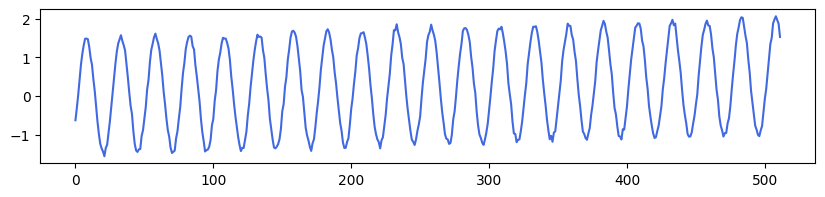

In [10]:
# Generating non-stationary samples
num_samples = 5
seq_len = 512
target_freq = 4.0
sample_rate = 100
nonstationary_samples = generate_nonstationary_sine(
    num_samples=num_samples, seq_len=seq_len, freq=target_freq, sample_rate=sample_rate
)
print(f"Non-stationary sample shape: {nonstationary_samples.shape}")

# Visualize the first non-stationary sample
plt.figure(figsize=(10, 2), dpi=100)
plt.plot(nonstationary_samples[0], color="royalblue")

We will then instantiate the ARIMA simulator and fit the generated non-stationary sinusoidal signal.

Since we need to perform a hyperparameter search (order determination) on the ARIMA model based on specific input data, the following code will take some time to execute.

In [3]:
# Instantiate the ARIMA simulator
simulator = ARIMASimulator(max_p=5, max_d=2, max_q=5)

# Fit the model; FIXME: consider adding a progress bar during fitting
simulator.fit(time_series=nonstationary_samples, select_order=True)

print(simulator.model_summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2560
Model:                 ARIMA(5, 0, 5)   Log Likelihood                2721.059
Date:                Sat, 14 Feb 2026   AIC                          -5418.119
Time:                        01:16:33   BIC                          -5347.946
Sample:                             0   HQIC                         -5392.673
                               - 2560                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2656      0.040      6.629      0.000       0.187       0.344
ar.L1          1.4198      0.470      3.024      0.002       0.499       2.340
ar.L2          0.6383      1.081      0.591      0.5

Selected ARIMA Order: p=5, d=0, q=5
ARIMA samples shape: (5, 512)


Text(0.5, 1.0, 'Generated ARIMA Samples')

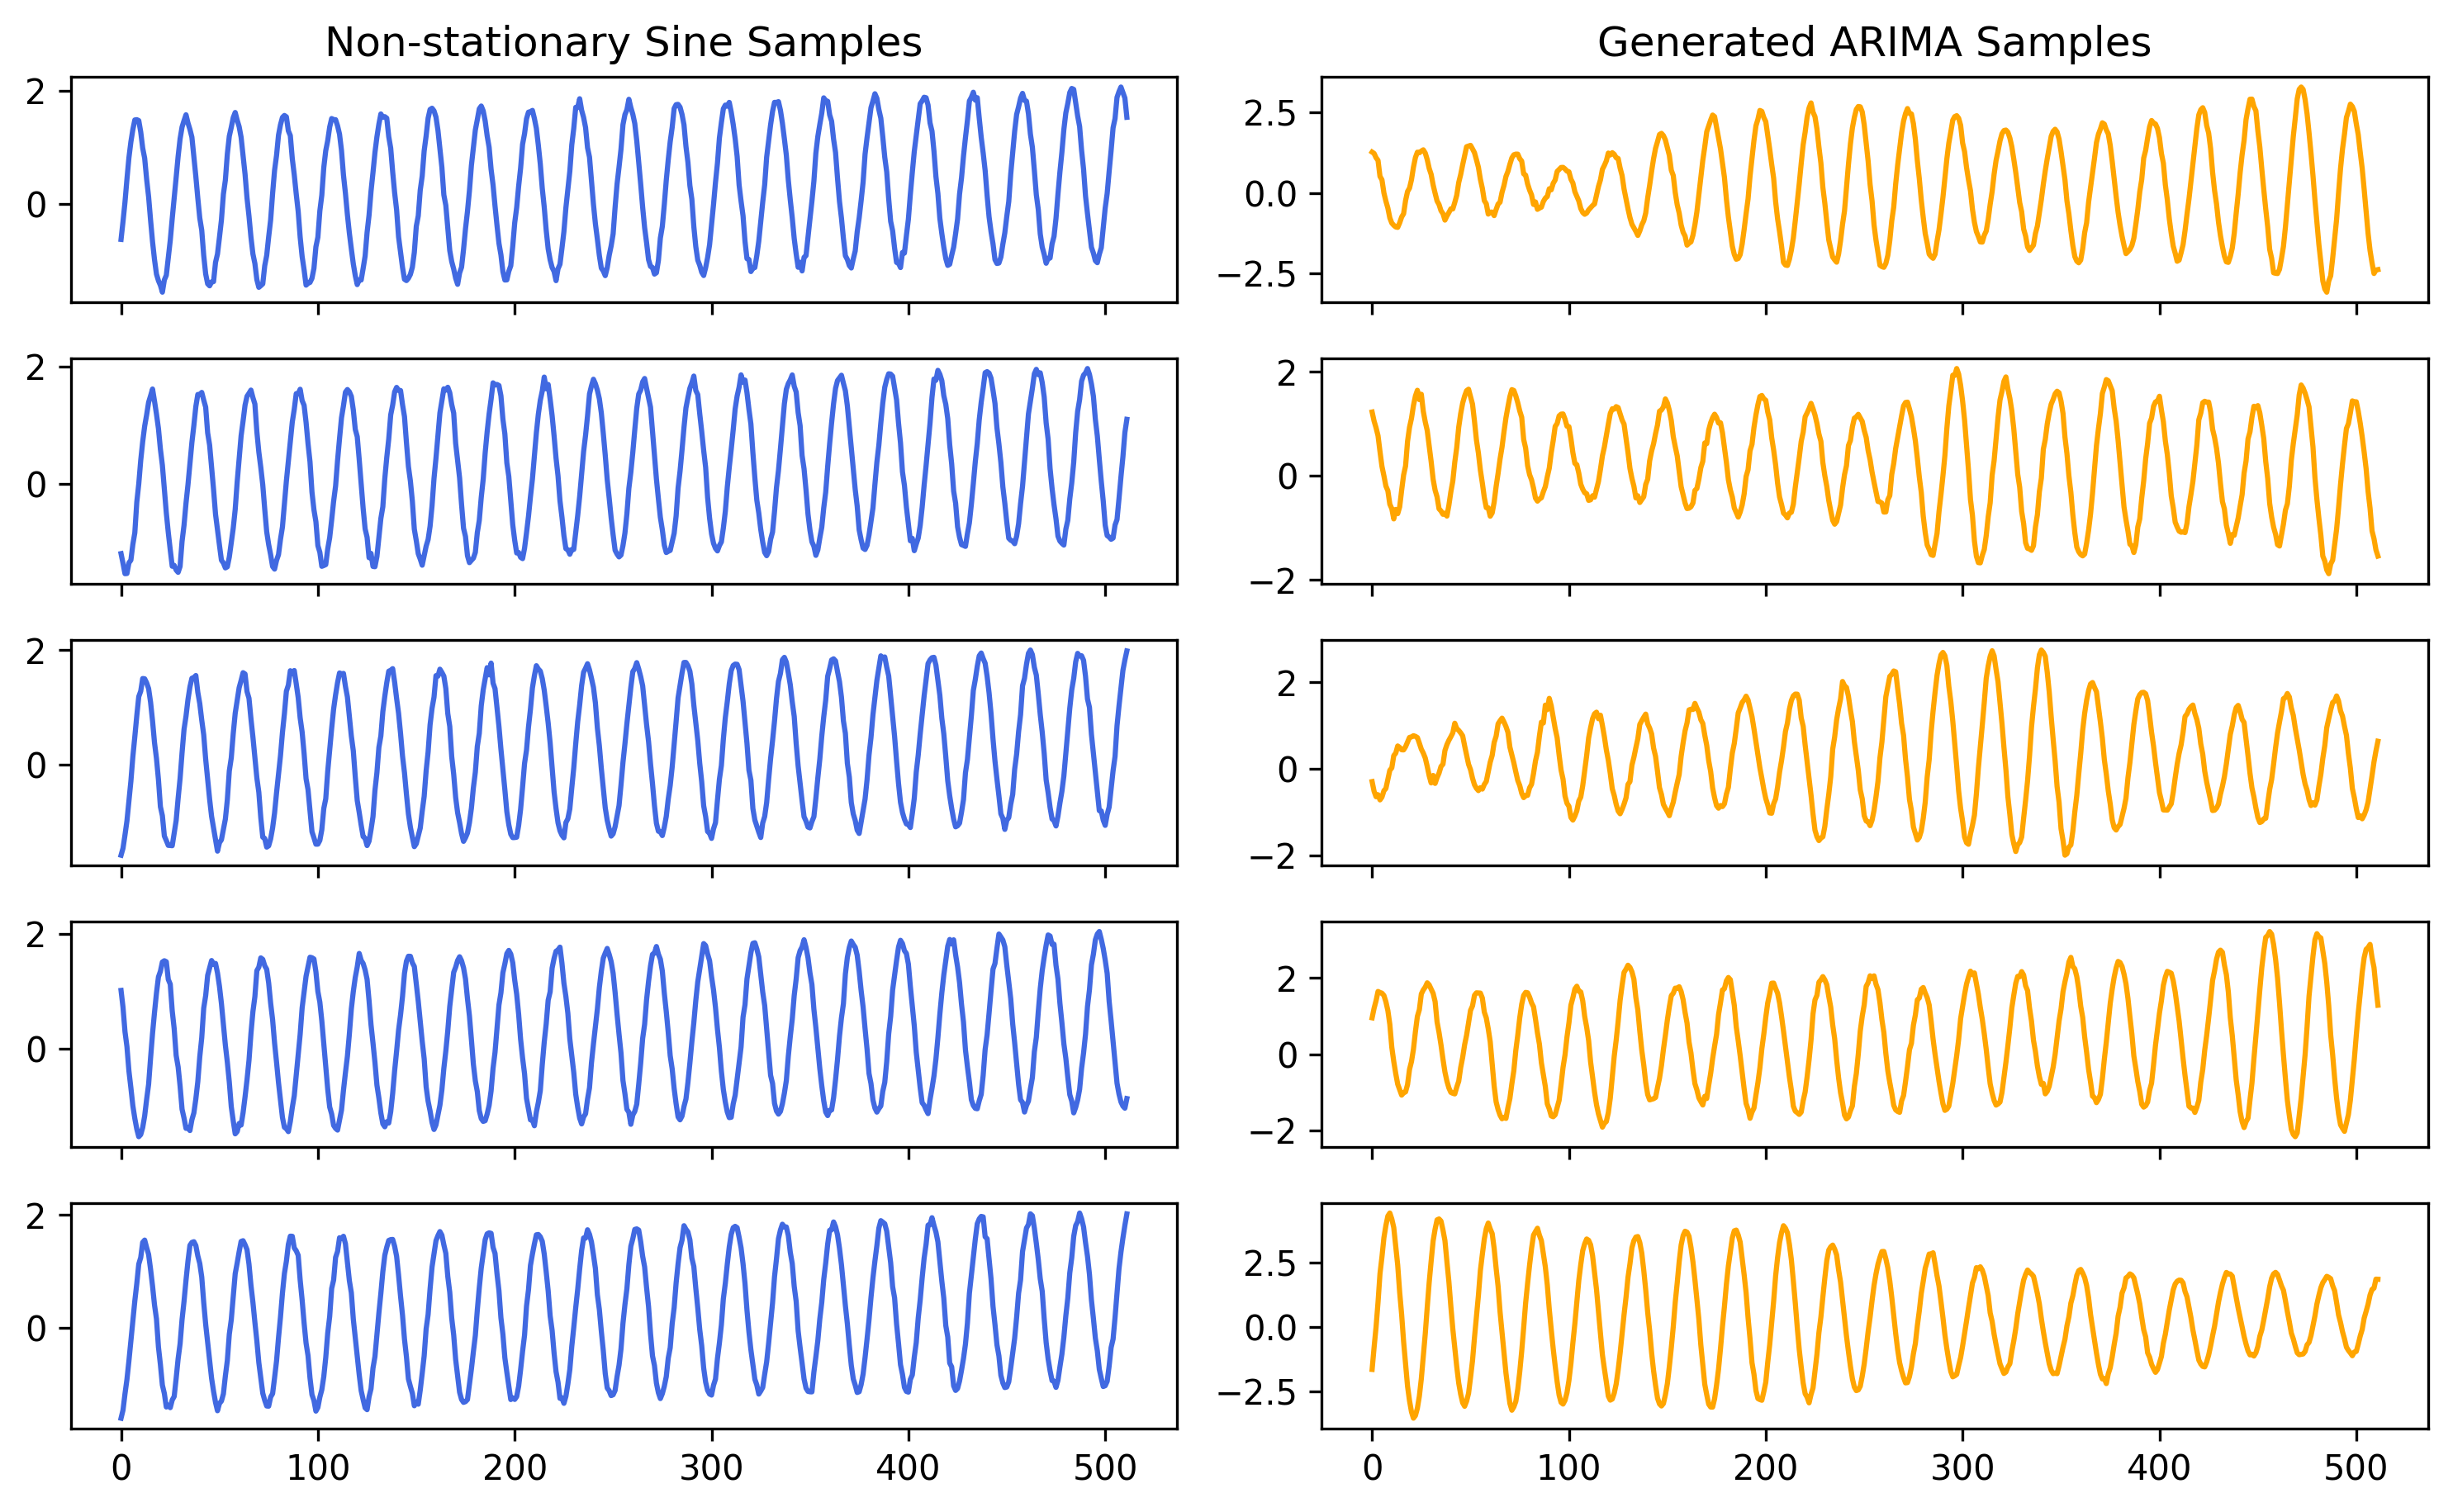

In [11]:
# The optimal model order determined by BIC
p, d, q = simulator.p_order, simulator.d_order, simulator.q_order
print(f"Selected ARIMA Order: p={p}, d={d}, q={q}")

# Generate ARIMA samples
arma_samples = simulator.transform(
    num_samples=num_samples, seq_len=seq_len, random_state=4
)

print("ARIMA samples shape:", arma_samples.shape)

fig, ax = plt.subplots(5, 2, figsize=(10, 6), dpi=300, sharex=True)

for i in range(num_samples):
    ax[i, 0].plot(nonstationary_samples[i], color="royalblue")
    ax[i, 1].plot(arma_samples[i], color="orange")

plt.tight_layout()
ax[0, 0].set_title("Non-stationary Sine Samples")
ax[0, 1].set_title("Generated ARIMA Samples")

ARIMA(p, d, q) 模型的使用在于模型的选择以及拟合的诊断。

我们提供了多种方法来帮助用户选择合适的模型阶数，包括 AIC、BIC、ACF、PACF 以及 EACF 方法。

对于AR模型，可以使用PACF图来选择阶数p；对于MA模型，可以使用ACF图来选择阶数q；对于ARMA模型，可以结合ACF和PACF图来选择合适的p和q。但由于 EACF 方法需要人为的进行主管判断，因此在自动定阶中我们通常使用AIC和BIC方法来选择模型阶数。

由于ARIMA模型包含差分阶数d，因此在选择模型时需要先对时间序列进行差分处理，直到序列平稳为止。然后再使用上述方法选择p和q。

In [12]:
# 对输入的信号进行平稳性检验
time_series = pd.Series(nonstationary_samples[0])
simulator.adf_test(time_series)

False

ADF 平稳性检验的结果显示该时间序列是非平稳的，因此我们需要对其进行差分处理以使其平稳。

Number of differences applied to achieve stationarity: 1
True


Text(0.5, 1.0, 'Differenced Stationary Time Series')

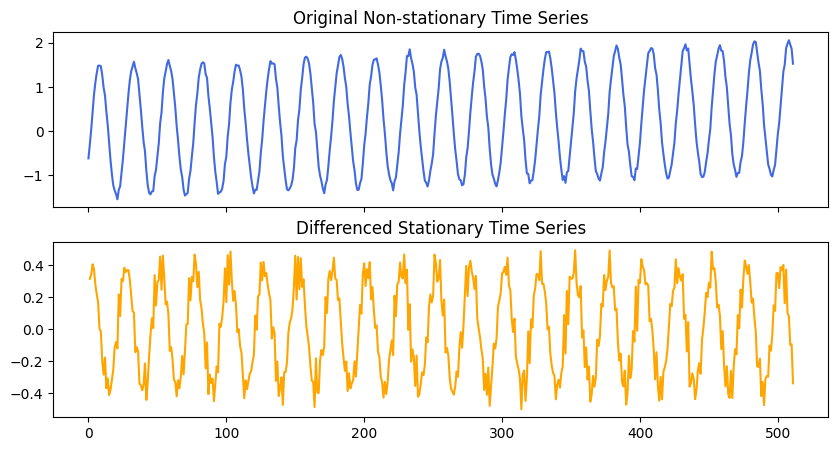

In [13]:
# 调用`diff_stationary`方法对时间序列进行差分平稳化处理
stationary_series, diff_count = simulator.diff_stationary(time_series=time_series)

print(f"Number of differences applied to achieve stationarity: {diff_count}")
# 对平稳化后的信号进行平稳性检验
print(simulator.adf_test(stationary_series))

# Visualize the original and differenced stationary time series
fig, ax = plt.subplots(2, 1, figsize=(10, 5), dpi=100, sharex=True)
ax[0].plot(time_series, color="royalblue")
ax[0].set_title("Original Non-stationary Time Series")
ax[1].plot(stationary_series, color="orange")
ax[1].set_title("Differenced Stationary Time Series")

After obtaining a stationary signal, our next step is to determine the orders p and q of the ARMA model. For manual, subjective selection, we can use the EACF method. For automatic order selection, we typically use the AIC and BIC methods.

The main advantage of EACF is that it does not require model fitting; it determines the order solely based on the residuals of the AR process. For specific usage instructions, please see: https://rdrr.io/cran/TSA/src/R/eacf.R

In [14]:
# Show the EACF matrix for determining ARMA orders
eacf_matrix, threshold, eacf_df = simulator.eacf(
    time_series=stationary_series, symbolize=True, max_ar=6, max_ma=6
)
print("EACF Matrix:")
print(eacf_matrix)
print("\nEACF DataFrame:")
print(eacf_df)

EACF Matrix:
[['x' 'x' 'x' 'x' 'x' 'o']
 ['x' 'x' 'x' 'x' 'o' 'o']
 ['x' 'x' 'x' 'x' 'x' 'o']
 ['x' 'o' 'x' 'x' 'o' 'o']
 ['x' 'x' 'x' 'x' 'x' 'o']
 ['x' 'x' 'x' 'x' 'x' 'x']
 ['x' 'x' 'x' 'o' 'x' 'x']]

EACF DataFrame:
          q=1       q=2       q=3       q=4       q=5       q=6
p=0  0.865060  0.815784  0.671777  0.496826  0.277605  0.053623
p=1 -0.230014  0.386919  0.159790  0.188924  0.042809 -0.002074
p=2  0.089756  0.383049  0.329045  0.257909  0.089951  0.012208
p=3 -0.148699  0.003374  0.370023  0.111020  0.004017  0.006051
p=4 -0.223729 -0.226253  0.094174  0.309613 -0.131003 -0.012209
p=5 -0.220549 -0.220188 -0.126824  0.126715  0.198876 -0.180241
p=6 -0.137920 -0.238221 -0.171418 -0.041384  0.106721  0.124444


一般来说，对于自动化算法我们通过使用AIC和BIC方法来选择ARMA模型的阶数。具体可以调用一下函数。该方法通过也被封装在了`fit`接口中。

In [15]:
# 通过AIC和BIC方法自动选择ARMA模型的阶数
aic_order = simulator.select_arma_order(stationary_series=stationary_series)

当确定好模型的阶数以后，就可以对模型进行拟合并对模型的拟合残差进行诊断。

理想情况下我们希望模型的残差是白噪声序列，因此我们可以通过对残差进行白噪声检验来判断模型的拟合效果。

在ARMASimulator类中我们提供了两种残差诊断方法，包括Ljung-Box和Shapiro-Wilk。

我们首先生成理想的白噪声序列并展示如何通过上述方法进行诊断.

Text(0.5, 1.0, 'Generated White Noise Series')

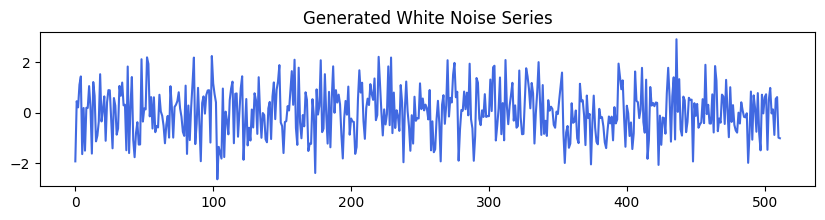

In [16]:
from statsmodels.stats.diagnostic import acorr_ljungbox
from s2generator.utils import plot_shapiro_wilk

# 生成理想的白噪声序列
white_noise = np.random.normal(loc=0.0, scale=1.0, size=512)

plt.figure(figsize=(10, 2), dpi=100)
plt.plot(white_noise, color="royalblue")
plt.title("Generated White Noise Series")

In [23]:
# 调用Ljung-Box方法对模型残差进行白噪声检验
lb_p = acorr_ljungbox(white_noise, return_df=True)
print("Ljung-Box Test p-values for residuals:")
print(np.mean(lb_p["lb_pvalue"]))
print("\nLjung-Box Test Results:")
print(np.all(lb_p["lb_pvalue"] > 0.05))

Ljung-Box Test p-values for residuals:
0.4346768907861785

Ljung-Box Test Results:
True


(<Figure size 6000x2500 with 2 Axes>, 0.996, 0.23)

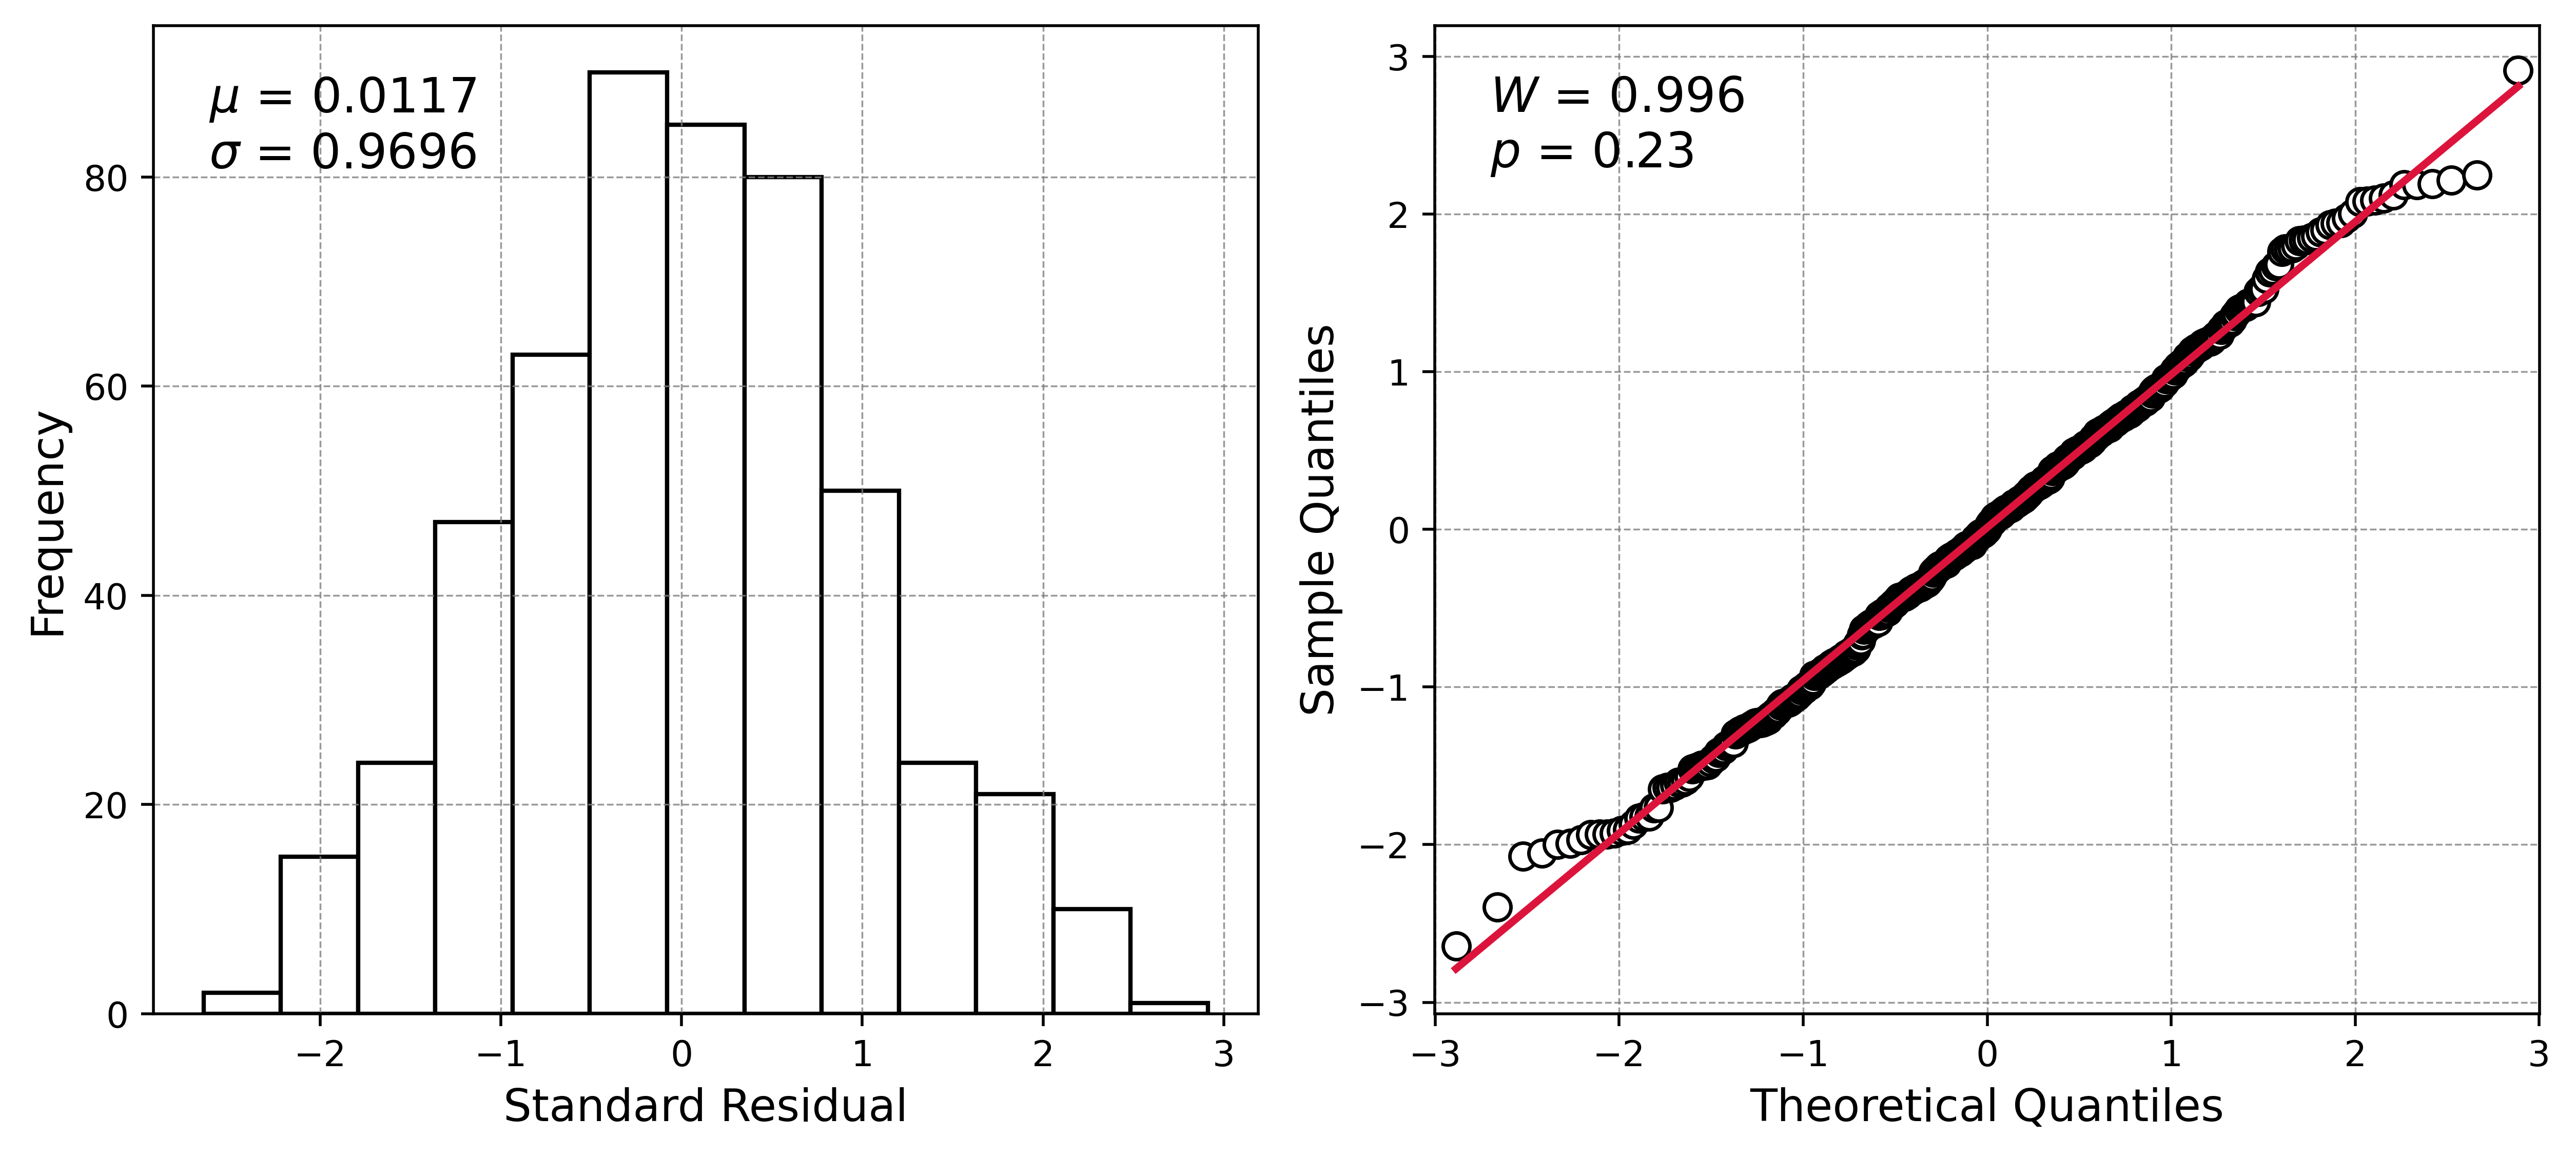

In [ ]:
# 对理想白噪声进行Shapiro-Wilk正态性检验
# 这里需要观察右侧Q-Q图的检验统计量和p值
plot_shapiro_wilk(white_noise)

In [21]:
# 调用Ljung-Box方法对模型残差进行白噪声检验
lb_p_values, results = simulator.residual_diagnosis()

print("Ljung-Box Test p-values for residuals:")
print(lb_p_values)
print("\nLjung-Box Test Results:")
print(results)

TypeError: 'float' object is not iterable

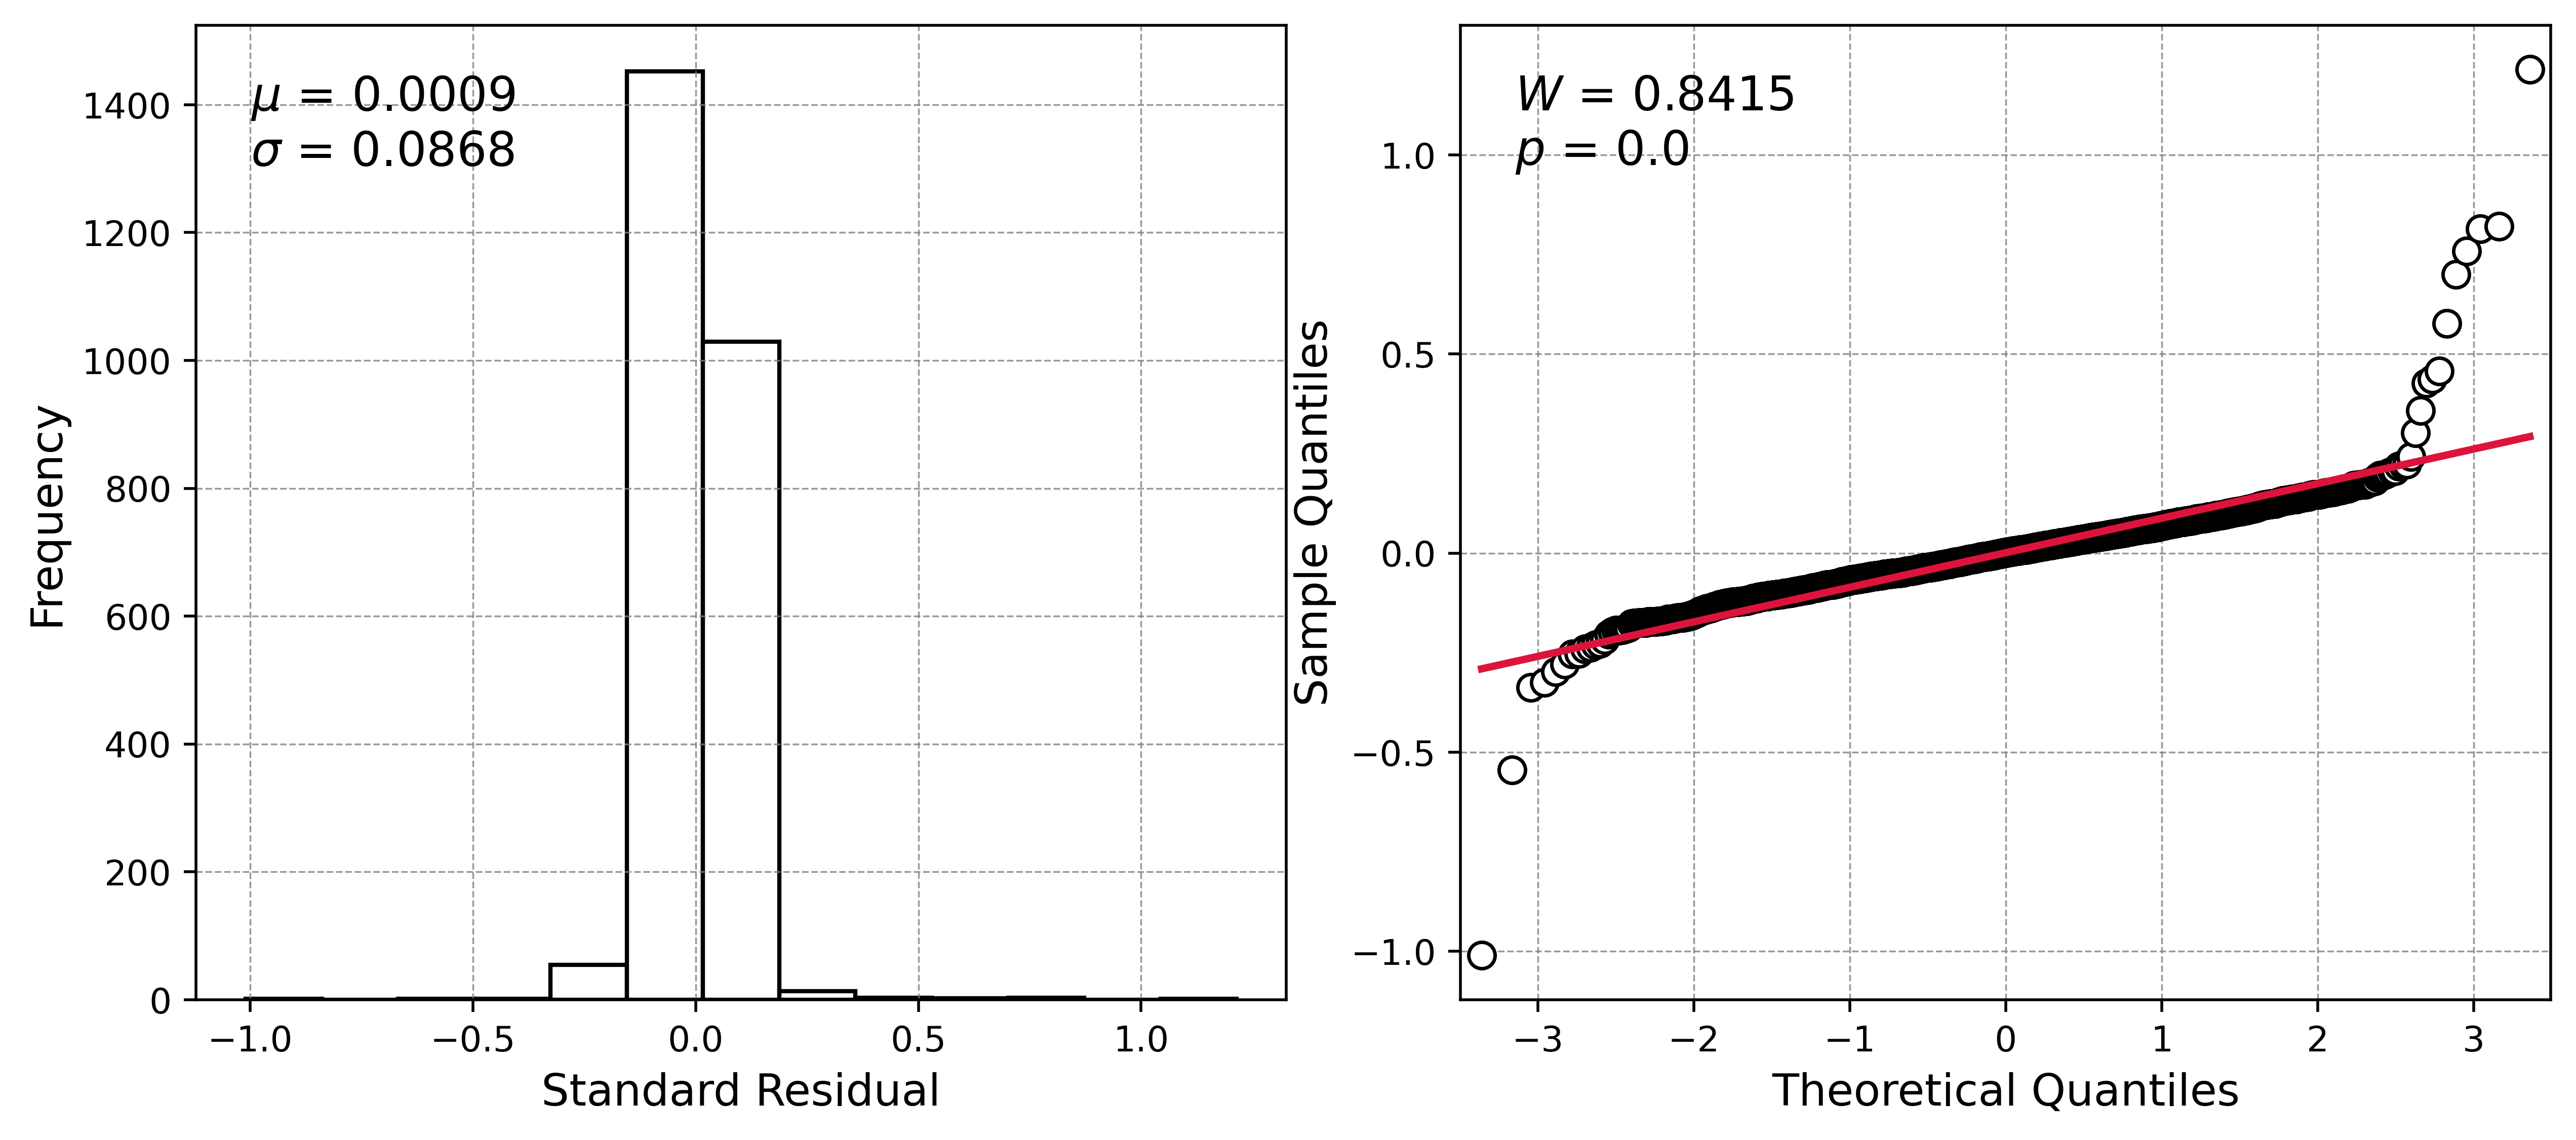

In [ ]:
# 对模型残差进行Shapiro-Wilk正态性检验
fig = simulator.plot_shapiro_wilk()